# Handling Missing Data in Machine Learning

This notebook walks through the most common strategies for dealing with missing values in a dataset, using scikit-learn and pandas. For every technique, we apply it on a real dataset, visualize the effect it has on the data (distribution, variance, outliers), and note down observations.

**Techniques covered:**
1. Complete Case Analysis (CCA)
2. Univariate Imputation — Numerical Data (Mean/Median)
3. Univariate Imputation — Categorical Data (Most Frequent / Mode)
4. Random Sample Imputation — Numerical & Categorical Data
5. Missing Indicator

**Datasets used:** `data_science_job.csv`, `titanic_toy.csv`, `train.csv` (House Prices), `Titanic-Dataset.csv`, `house-train.csv`



## 1. Complete Case Analysis (CCA)

**Complete Case Analysis** means simply dropping every row that has at least one missing value, and keeping only the "complete" rows.

It's a valid strategy only when:
- The data is missing completely at random (MCAR)
- The proportion of missing values in a column is small (commonly, **less than 5%**)

If these conditions don't hold, CCA can introduce bias and/or throw away too much data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


Let's check what percentage of values are missing in each column.

In [3]:
df.isnull().mean() * 100
# Percentage of missing values in each column

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [4]:
df.shape

(19158, 13)

**Rule of thumb:** CCA is only applied to columns whose missing values are below 5%. Let's fetch just those columns.

In [5]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [6]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
8266,0.925,no_enrollment,Graduate,20.0,108.0
6211,0.896,no_enrollment,High School,9.0,51.0
18569,0.624,no_enrollment,Graduate,4.0,38.0
11152,0.910,no_enrollment,High School,2.0,37.0
11113,0.624,no_enrollment,Graduate,3.0,10.0


Before dropping rows, let's check how much of the dataset survives Complete Case Analysis.

In [7]:
len(df[cols].dropna()) / len(df)
# ~89% of the data remains after CCA -> acceptable data loss

0.8968577095730244

Now we actually perform CCA and compare the shape of the dataset before and after.

In [8]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

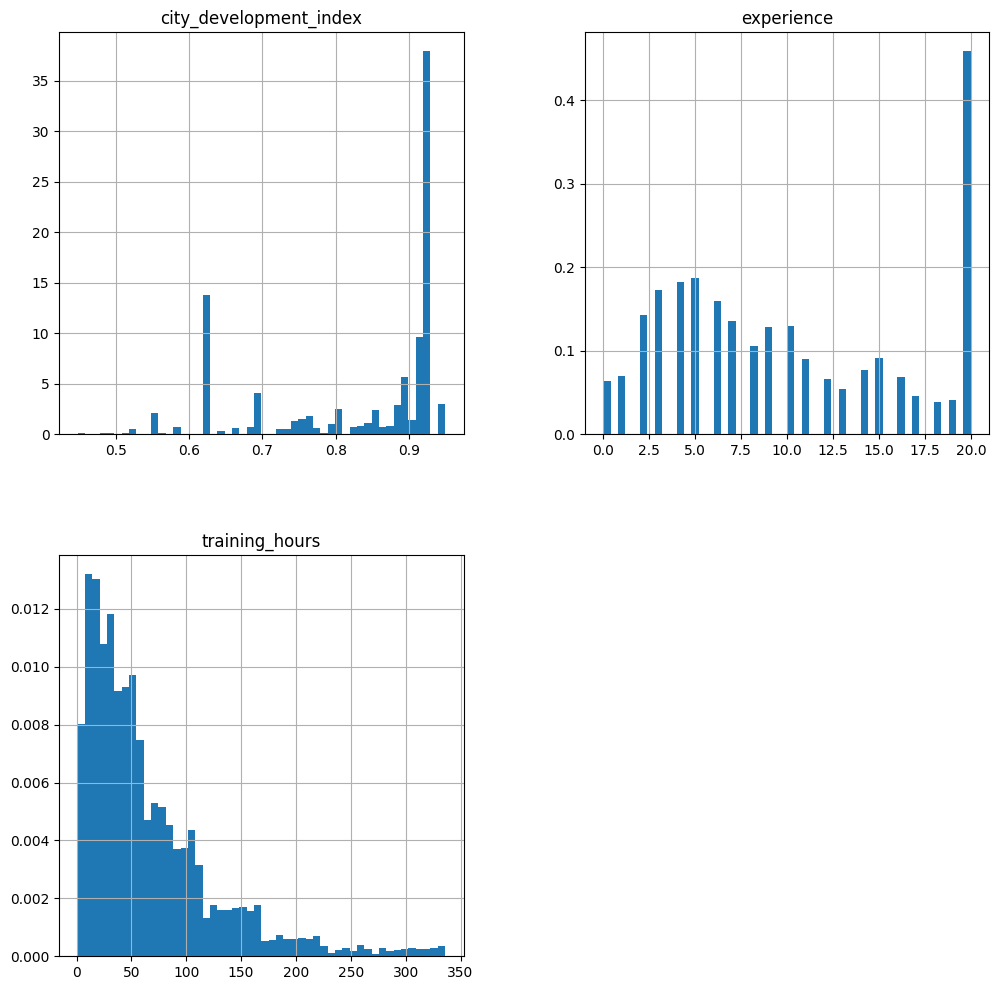

In [9]:
new_df.hist(bins=50, density=True, figsize=(12, 12))
plt.show()

**About the plot above:** this shows the distribution of every retained column *after* CCA. The goal of the next few plots is to overlay the *original* distribution (red) with the *post-CCA* distribution (green) for individual columns, to visually confirm CCA hasn't distorted the data.

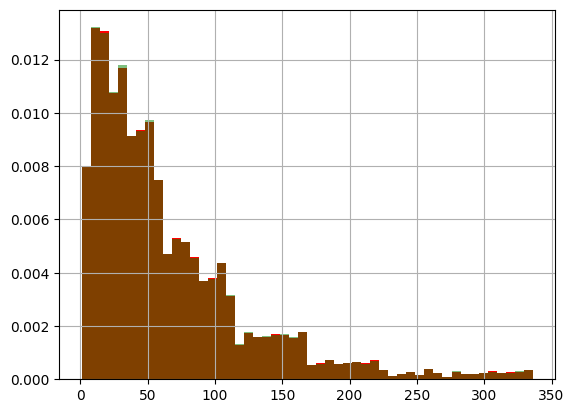

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca (alpha makes the color transparent so we can see the overlay of both distributions)
new_df['training_hours'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.5)
plt.show()

**Observation:** The red (original) and green (post-CCA) histograms for `training_hours` overlap almost perfectly, confirming CCA did not distort this variable's distribution.

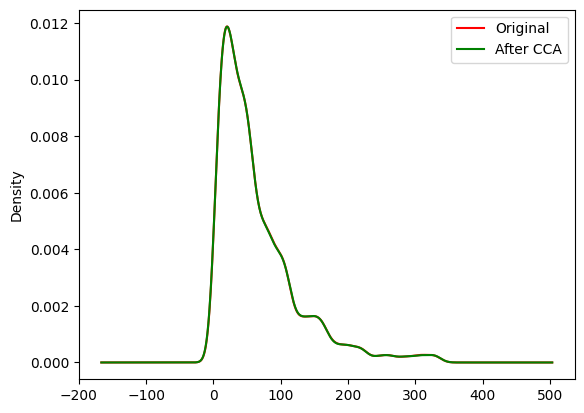

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['training_hours'].plot.density(color='red')
new_df['training_hours'].plot.density(color='green')
plt.legend(['Original', 'After CCA'])
plt.show()

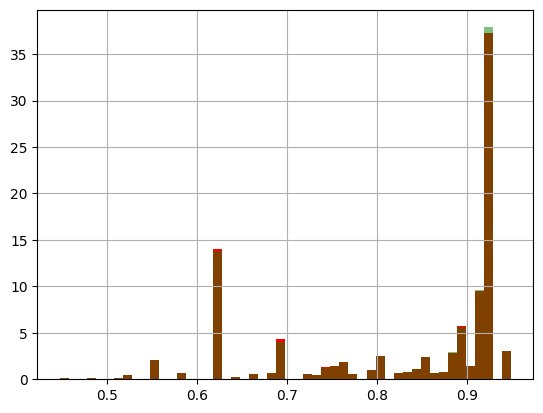

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')
new_df['city_development_index'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.5)
plt.show()

**Observation:** Same story for `city_development_index` — the two distributions line up closely.

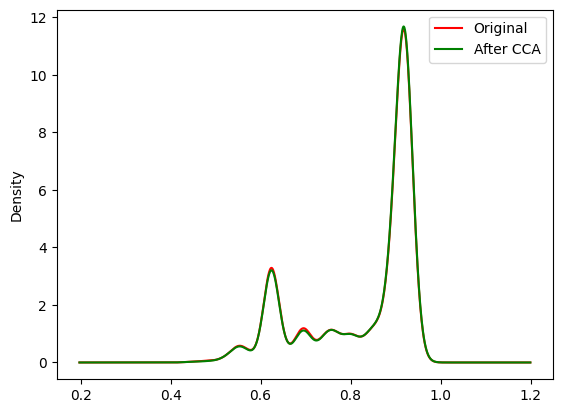

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['city_development_index'].plot.density(color='red')
new_df['city_development_index'].plot.density(color='green')
plt.legend(['Original', 'After CCA'])
plt.show()

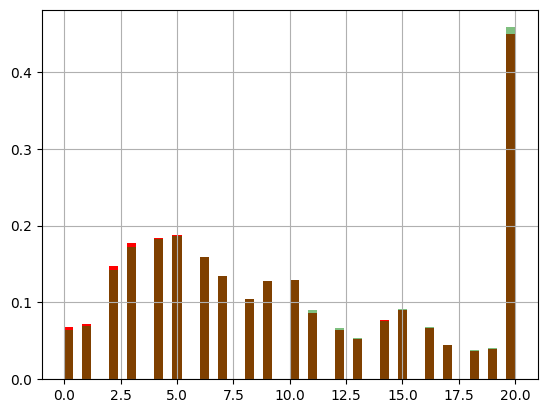

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['experience'].hist(bins=50, ax=ax, density=True, color='red')
new_df['experience'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.5)
plt.show()

**Observation:** `experience` also shows a good overlap between original and post-CCA distributions.

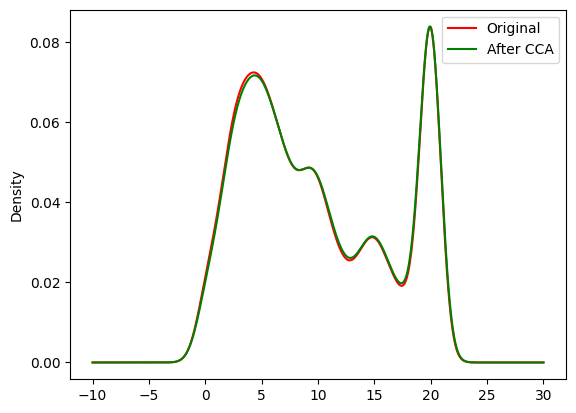

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['experience'].plot.density(color='red')
new_df['experience'].plot.density(color='green')
plt.legend(['Original', 'After CCA'])
plt.show()

For categorical columns, we compare the proportion of each category before and after CCA instead of a density plot.

In [16]:
temp = pd.concat([
            df['enrolled_university'].value_counts() / len(df),
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)
temp.columns = ['original', 'after_cca']
temp

,original,after_cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [17]:
temp = pd.concat([
            df['education_level'].value_counts() / len(df),
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)
temp.columns = ['original', 'after_cca']
temp

,original,after_cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


### Observation & Conclusion — CCA

- For every numerical (`training_hours`, `city_development_index`, `experience`) and categorical (`enrolled_university`, `education_level`) column checked, the distribution barely changed after dropping incomplete rows.
- We retained **~89%** of the data, which is an acceptable trade-off.
- **Conclusion:** CCA was a safe choice here because the missing values were under 5% per column and the data appears to be missing completely at random (MCAR). CCA should **not** be used when missing percentage is high, or when missingness is related to the outcome — it would introduce bias and discard too much useful data.

## 2. Univariate Imputation

**Univariate imputation** fills missing values in a column using statistics derived from that *same* column (e.g., mean, median, mode) — as opposed to multivariate methods that use other columns to predict the missing value.

### 2.1 Imputing Numerical Data — Using Pandas

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [19]:
df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [20]:
df.isnull().mean()
# 'Age' has ~19% missing values, 'Fare' has ~5%

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [21]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [22]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [23]:
X_train.isnull().mean()

,0
Age,0.207865
Fare,0.050562
Family,0.000000


We compute the mean and median of `Age` and `Fare` **from the training set only**, to avoid data leakage.

In [24]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

Now we create new columns holding the mean- and median-imputed versions of `Age` and `Fare`, so we can compare them against the original.

In [25]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [26]:
X_train.sample(5)
# The new columns show the missing values replaced by the mean/median

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
24,8.00,21.0750,4,8.00,8.000000,21.0750,21.0750
21,34.00,13.0000,0,34.00,34.000000,13.0000,13.0000
584,NaN,8.7125,0,28.75,29.785904,8.7125,8.7125
31,NaN,146.5208,1,28.75,29.785904,146.5208,146.5208
803,0.42,8.5167,1,0.42,0.420000,8.5167,8.5167


**Effect on variance:** filling in missing values with a single constant value (mean/median) artificially reduces the variance of the column, since we're replacing spread-out unknowns with one repeated number.

In [27]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age variance after median imputation: ', X_train['Age_median'].var())
print('Age variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare variance after median imputation: ', X_train['Fare_median'].var())
print('Fare variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  204.3495133904614
Age variance after median imputation:  161.9895663346054
Age variance after mean imputation:  161.81262452718673
Original Fare variable variance:  2448.197913706318
Fare variance after median imputation:  2340.0910219753637
Fare variance after mean imputation:  2324.2385256705547


**About the plot below:** we overlay the KDE (density) curve of the original `Age` column against its mean- and median-imputed versions, to see how much the imputation distorts the distribution's shape.

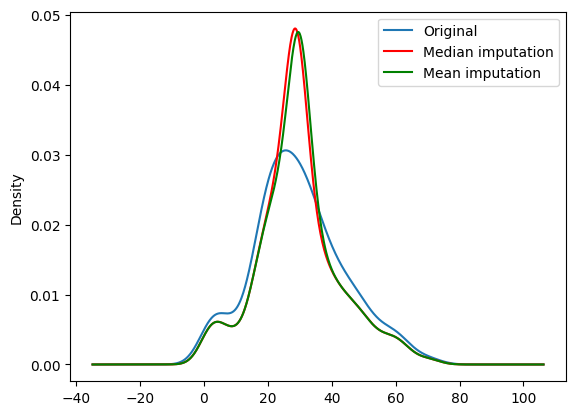

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original', 'Median imputation', 'Mean imputation']
ax.legend(lines, labels, loc='best')
plt.show()

**Observation (Age):** There's a noticeable spike near the imputed value — a red flag, since a large chunk of the data now piles up at a single point, distorting the natural shape of the distribution.

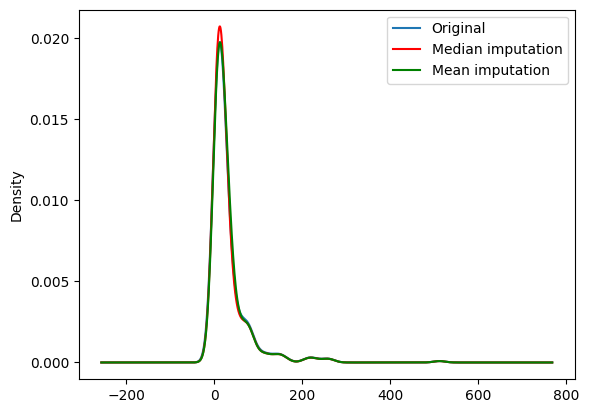

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original', 'Median imputation', 'Mean imputation']
ax.legend(lines, labels, loc='best')
plt.show()

**Observation (Fare):** Here the imputed curves closely track the original — a green flag, since `Fare` had a much smaller proportion of missing values (~5%), so imputation barely disturbs the overall shape.

In [30]:
# Checking covariance with other columns
X_train.cov(numeric_only=True)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


In [31]:
# Checking correlation with other columns
X_train.corr(numeric_only=True)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.090156
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205942,0.205499
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086982,0.089673
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083461,0.086078
Fare_median,0.087356,1.000000,0.205942,0.086982,0.083461,1.000000,0.996607
Fare_mean,0.090156,1.000000,0.205499,0.089673,0.086078,0.996607,1.000000


**About the plot below:** boxplots let us check whether imputation introduced new outliers into the columns.

<Axes: >

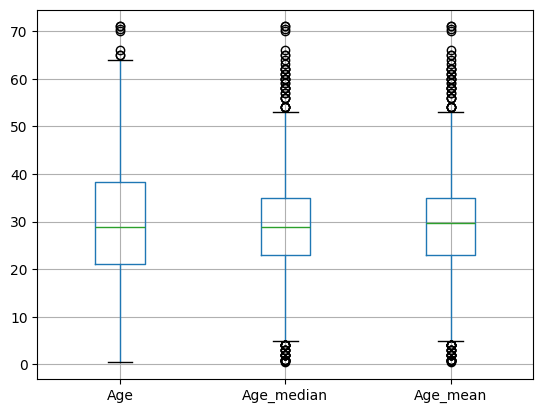

In [32]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

**Observation:** the number of outliers visibly increases after imputing `Age` — another sign that mean/median imputation isn't ideal for this column.

<Axes: >

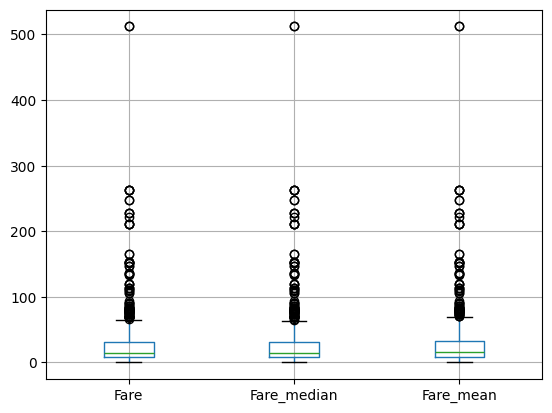

In [33]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

**Observation:** for `Fare`, the outlier count stays roughly the same before and after imputation.

### Observation & Conclusion — Mean/Median Imputation

- For **`Fare`** (low missing %), mean/median imputation preserved the distribution, variance, and outlier profile reasonably well.
- For **`Age`** (higher missing %, ~19%), imputation noticeably distorted the distribution, reduced variance, and increased outliers.
- **Conclusion:** simple mean/median imputation works best when the missing percentage is small. As the missing percentage grows, this method increasingly distorts the data — a more sophisticated technique (e.g., random sample imputation, or model-based imputation) should be preferred.

### 2.2 Imputing Numerical Data — Using Scikit-learn

We can reproduce the same median/mean imputation more conveniently (and consistently) using `SimpleImputer` combined with a `ColumnTransformer`.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [35]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [36]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [37]:
trf.fit(X_train)
print("Model trained")

Model trained


In [38]:
trf.named_transformers_['imputer1'].statistics_
# median value learned for 'Age'

array([28.75])

In [39]:
trf.named_transformers_['imputer2'].statistics_
# mean value learned for 'Fare'

array([32.61759689])

Once fit on the training data, we use the **same** learned statistics to transform both the train and test sets (never re-fit on test data, to avoid leakage).

In [40]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [41]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])

**Why use `SimpleImputer` instead of manual `fillna`?** It fits neatly into scikit-learn pipelines, guarantees the exact same statistic learned on the training set is applied consistently to the test set, and avoids the risk of accidentally leaking test-set information into training.

### 2.3 Imputing Categorical Data

For categorical columns we typically impute the missing values with the **mode** (most frequent category), since mean/median don't make sense for non-numeric data.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
df = pd.read_csv('train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [44]:
df.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

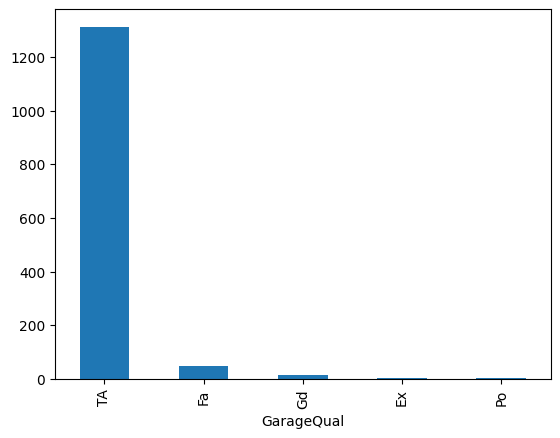

In [45]:
df['GarageQual'].value_counts().plot(kind='bar')

In [46]:
df['GarageQual'].mode()
# Most frequent category is 'TA'

,GarageQual
0,TA


**About the plot below:** we compare the distribution of `SalePrice` for houses where `GarageQual == 'TA'` against houses where `GarageQual` is missing. If the two curves look similar, it supports imputing missing values with the mode.

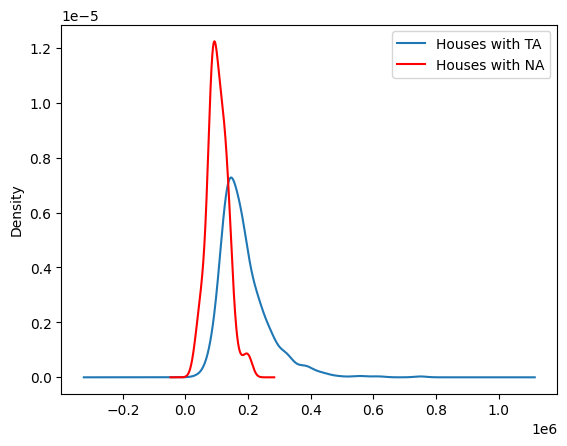

In [47]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')
plt.show()

In [48]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

In [49]:
df['GarageQual'].fillna('TA', inplace=True)

/tmp/ipykernel_411/1818999247.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA', inplace=True)


<Axes: xlabel='GarageQual'>

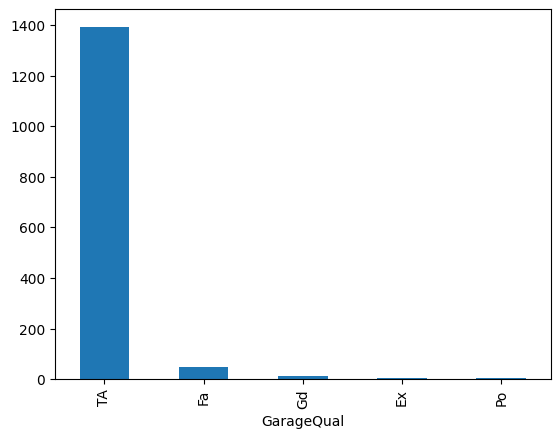

In [50]:
df['GarageQual'].value_counts().plot(kind='bar')

**About the plot below:** now we overlay the *original* `SalePrice` distribution for `TA` houses against the *post-imputation* distribution, to check the imputation didn't distort the target relationship.

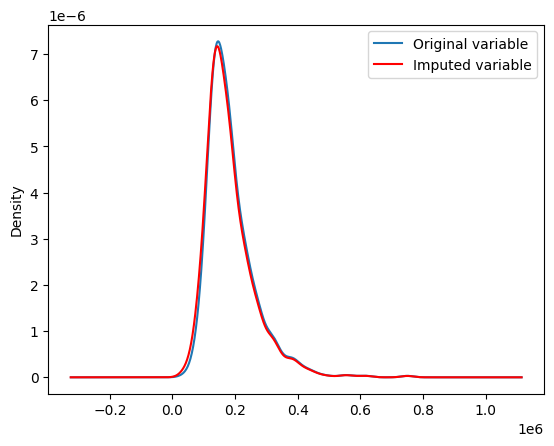

In [51]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')
plt.show()

**Observation (GarageQual):** the curves before and after imputation stay very close — mode imputation was a safe choice here since `TA` was already the dominant category.

Repeating the same process for `FireplaceQu`.

<Axes: xlabel='FireplaceQu'>

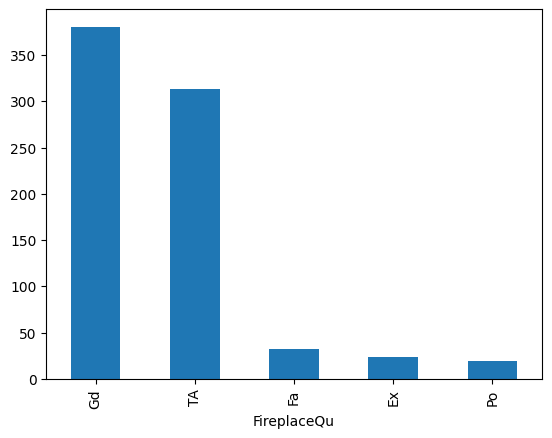

In [52]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [53]:
df['FireplaceQu'].mode()
# Most frequent category is 'Gd'

,FireplaceQu
0,Gd


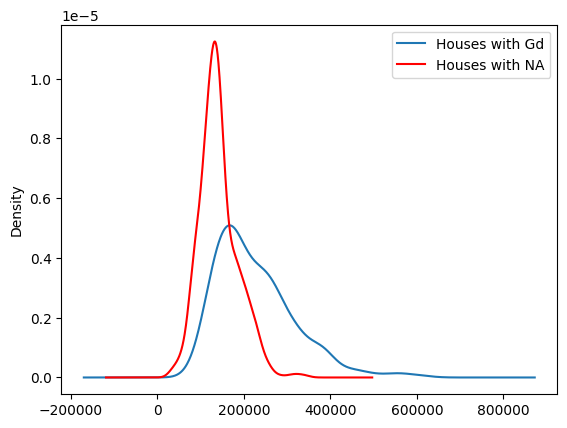

In [54]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')
plt.show()

In [55]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [56]:
df['FireplaceQu'].fillna('Gd', inplace=True)

/tmp/ipykernel_411/3912738894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


<Axes: xlabel='FireplaceQu'>

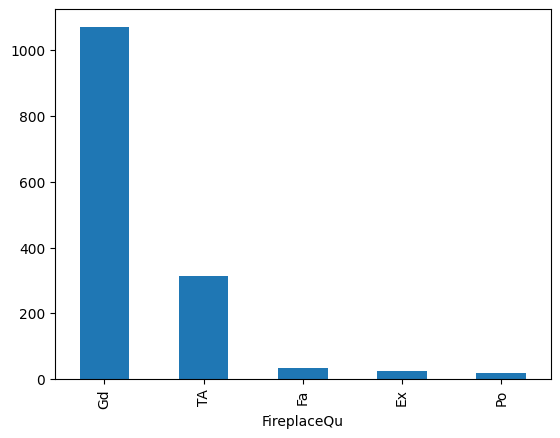

In [57]:
df['FireplaceQu'].value_counts().plot(kind='bar')

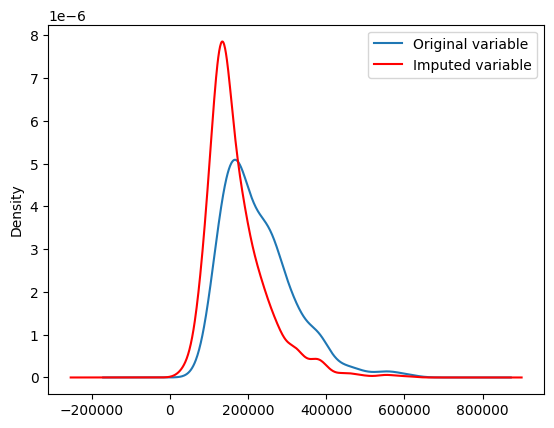

In [58]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')
plt.show()

**Observation (FireplaceQu):** unlike `GarageQual`, the houses that had a missing `FireplaceQu` (likely meaning *no fireplace*) show a visibly different `SalePrice` distribution than houses with `Gd` fireplaces. Filling with the mode here changes the relationship between the feature and the target more noticeably.

Finally, let's reproduce this with `SimpleImputer(strategy='most_frequent')`.

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['SalePrice']), df['SalePrice'], test_size=0.2)

In [60]:
from sklearn.impute import SimpleImputer

In [61]:
imputer = SimpleImputer(strategy='most_frequent')

In [62]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [63]:
imputer.statistics_
# Most frequent value learned for each column

array(['Gd', 'TA'], dtype=object)

### Observation & Conclusion — Categorical Imputation

- Mode imputation worked well for `GarageQual`, where the missing category behaved similarly to the mode category.
- It was less appropriate for `FireplaceQu`, where "missing" likely encodes real information (no fireplace) rather than being random, and this changed the SalePrice relationship.
- **Conclusion:** always check whether "missing" carries meaning before blindly imputing with the mode — in cases like `FireplaceQu`, it may be better to treat "Missing" as its own category instead of imputing it away.

## 3. Random Sample Imputation

**Random Sample Imputation** fills missing values by randomly drawing from the observed (non-missing) values of the *same* column. Unlike mean/median imputation, this preserves the original variance and distribution shape much better, since we're not collapsing everything to a single value.

### 3.1 Numerical Data

In [64]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv('/content/Titanic-Dataset.csv', usecols=['Age', 'Fare', 'Survived'])

In [66]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [67]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [68]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

First, we duplicate the `Age` column into a new `Age_imputed` column, which is where we'll fill in the random samples (keeping the original `Age` untouched for comparison).

In [69]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [70]:
X_test.tail()
# 'Age_imputed' currently has the exact same values as 'Age'

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


Now we replace the missing values in `Age_imputed` with values randomly sampled from the non-missing `Age` values.

In [71]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(), random_state=0).values
)
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age'].dropna().sample(X_test['Age'].isnull().sum(), random_state=0).values
)

**About the plot below:** comparing the KDE of the original `Age` column against the random-sample-imputed version.

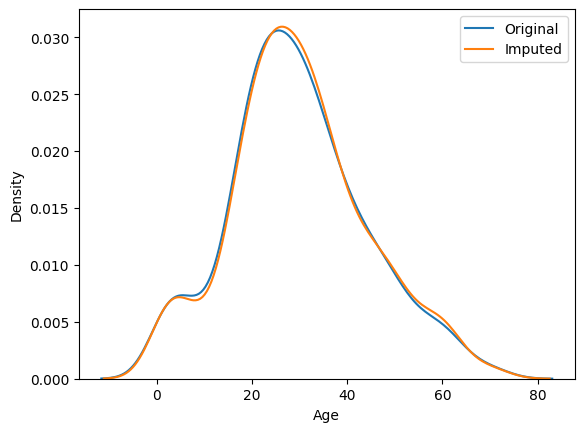

In [72]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

**Observation:** the two curves overlap almost perfectly — a clear improvement over mean/median imputation, which introduced a visible spike.

In [73]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  204.96152644874317


**Observation:** the variance after random sample imputation stays very close to the original variance — unlike mean/median imputation which artificially shrank it.

In [74]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,63.137063
Age,71.512440,204.349513,204.349513
Age_imputed,63.137063,204.349513,204.961526


<Axes: >

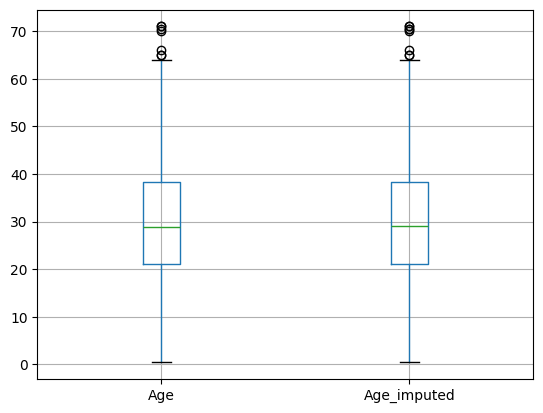

In [75]:
X_train[['Age', 'Age_imputed']].boxplot()

### Observation & Conclusion — Random Sample Imputation (Numerical)

Random sample imputation preserved the distribution shape and variance of `Age` far better than mean/median imputation did, without introducing many new outliers. The main trade-off is a small amount of randomness (results can differ slightly across runs unless a random seed is fixed), and it's slightly more complex to implement/maintain in a production pipeline than `SimpleImputer`.

### 3.2 Categorical Data

The same technique applies directly to categorical columns — we just sample from the observed categories instead of numeric values.

In [76]:
data = pd.read_csv('house-train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [77]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [78]:
data.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [79]:
X = data
y = data['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [80]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [81]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1236,NaN,TA,175500,TA,NaN
127,TA,NaN,87000,NaN,TA
379,TA,TA,179000,TA,TA
995,NaN,TA,121600,TA,NaN
234,TA,TA,216500,TA,TA


Same approach as before: replace the missing values in the `_imputed` columns with random samples drawn from the observed values of the same column.

In [82]:
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum(), random_state=0).values
)
X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum(), random_state=0).values
)

In [83]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [84]:
temp
# Category proportions for 'GarageQual' stay almost identical before/after imputation

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [85]:
X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum(), random_state=0).values
)
X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum(), random_state=0).values
)

In [86]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']
temp
# Category proportions for 'FireplaceQu' are also well preserved

,original,imputed
Gd,0.494272,0.497432
TA,0.412439,0.410103
Fa,0.040917,0.041096
Po,0.027823,0.026541
Ex,0.024550,0.024829


**About the plots below:** we plot the `SalePrice` KDE for each category of `FireplaceQu` before and after imputation, to visually confirm the category-vs-target relationship is preserved.

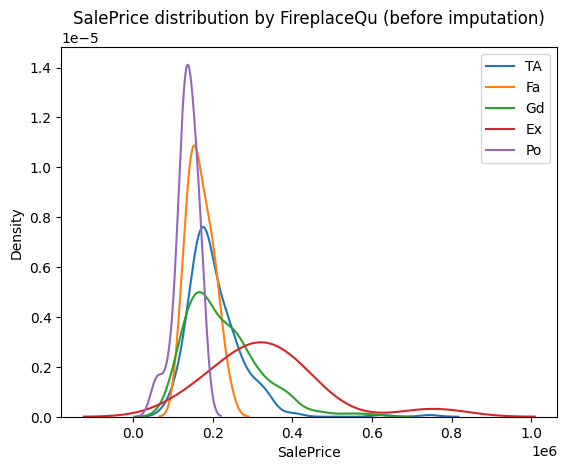

In [87]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label=category)
plt.legend()
plt.title('SalePrice distribution by FireplaceQu (before imputation)')
plt.show()

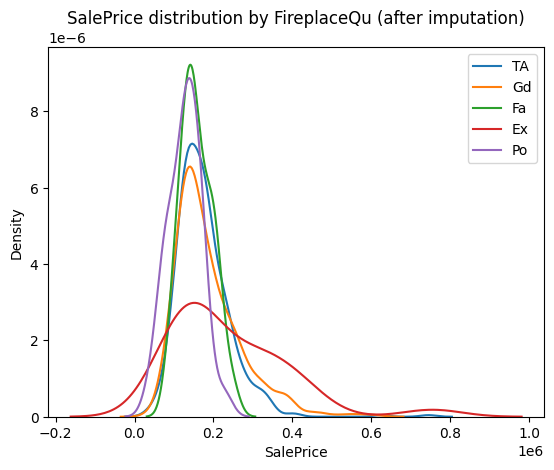

In [88]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category)
plt.legend()
plt.title('SalePrice distribution by FireplaceQu (after imputation)')
plt.show()

### Observation & Conclusion — Random Sample Imputation (Categorical)

The category proportions and the per-category `SalePrice` distributions stayed nearly identical before and after imputation for both `GarageQual` and `FireplaceQu`. Random sample imputation is a strong general-purpose choice for categorical columns when we don't want to bias the data toward a single dominant category (like mode imputation would).

## 4. Missing Indicator

Sometimes the *fact that a value is missing* is itself informative (i.e., MNAR — Missing Not At Random). A **Missing Indicator** is a new binary column that flags whether the original value was missing (`1`) or present (`0`), added *alongside* an imputed version of the column. This lets a downstream model use both the imputed value **and** the information that it was originally missing.

We'll compare a baseline Logistic Regression model with plain imputation against one that additionally uses a missing indicator column, and check whether accuracy improves.

In [89]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.impute import MissingIndicator, SimpleImputer

In [90]:
df = pd.read_csv('/content/Titanic-Dataset.csv', usecols=['Age', 'Fare', 'Survived'])

In [91]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [92]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [93]:
X_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


**Baseline: without a missing indicator** — just impute and train.

In [94]:
si = SimpleImputer()
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [95]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_trf, y_train)
y_pred = clf.predict(X_test_trf)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6145251396648045

**With a missing indicator** — add a binary flag column for missing `Age` values before training.

In [96]:
mi = MissingIndicator()
mi.fit(X_train)

MissingIndicator()

In [97]:
X_train_missing = mi.transform(X_train)
X_test_missing = mi.transform(X_test)

In [98]:
X_train['Age_NA'] = X_train_missing

In [99]:
X_train.sample(5)
# 'Age_NA' is 1 wherever Age was originally missing, 0 otherwise

,Age,Fare,Age_NA
3,35.0,53.1000,False
52,49.0,76.7292,False
94,59.0,7.2500,False
138,16.0,9.2167,False
77,NaN,8.0500,True


In [100]:
X_test['Age_NA'] = X_test_missing

In [101]:
si = SimpleImputer()

X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [102]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_trf2, y_train)
y_pred = clf.predict(X_test_trf2)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)
# Accuracy improves slightly compared to the baseline without the indicator

0.6312849162011173

The same result can be achieved more conveniently by passing `add_indicator=True` directly to `SimpleImputer`, without manually creating a `MissingIndicator` object.

In [103]:
si = SimpleImputer(add_indicator=True)
X_train_final = si.fit_transform(X_train)
X_test_final = si.transform(X_test)

In [104]:
clf = LogisticRegression()
clf.fit(X_train_final, y_train)
y_pred = clf.predict(X_test_final)
accuracy_score(y_test, y_pred)

0.6312849162011173

### Observation & Conclusion — Missing Indicator

Adding a missing indicator column for `Age` gave a small accuracy improvement over plain imputation alone, suggesting that whether `Age` was missing carries a small amount of predictive signal (consistent with MNAR-like behavior in the Titanic dataset). `SimpleImputer(add_indicator=True)` is the most convenient way to get this benefit in practice, since it avoids manually managing a separate `MissingIndicator` object.

## Overall Conclusion

| Technique | Best used when | Key risk |
|---|---|---|
| Complete Case Analysis | Missing % is small (<5%) and MCAR | Loses data; biased if not MCAR |
| Mean/Median Imputation | Quick baseline, low missing % | Reduces variance, distorts distribution, adds outliers |
| Mode Imputation (categorical) | Low missing %, "missing" isn't meaningful | Over-represents the dominant category |
| Random Sample Imputation | Want to preserve distribution & variance | Adds randomness; needs a fixed seed for reproducibility |
| Missing Indicator | Missingness itself is informative (MNAR) | Adds extra dimensionality to the feature set |

There is no universally "best" method — the right choice depends on **how much** data is missing and **why** it's missing (MCAR, MAR, or MNAR). Always visualize the effect of imputation on distribution, variance, and outliers before committing to a strategy.